In [118]:
import numpy as np
import sys
import pandas as pd
import time

In [137]:
import importlib
importlib.reload(visual)
importlib.reload(split)
importlib.reload(prep)
importlib.reload(MLP)
importlib.reload(util)
importlib.reload(sgs)
importlib.reload(pytorch)

sys.path.append("../src") 
import visualization as visual
import data_splitting as split
import preprocessing as prep
import neural_network as MLP
import utils as util
import stage_grid_search as sgs
import pytorch_models as pytorch

In [120]:
# cargo los datasets
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
1) Análisis y Preprocesamiento de Datos
</h1>

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.a) Examinar el dataset
</h3>

In [ ]:
# dimensiones y tipos
print("Shape X:", X_images.shape)
print("Shape y:", y_images.shape)

print("Tipo X:", X_images.dtype)
print("Tipo y:", y_images.dtype)

Shape X: (809555, 28, 28)
Shape y: (809555,)
Tipo X: uint8
Tipo y: uint8


El conjunto de imágenes `X_images` posee dimensión `(809555, 28, 28)`, lo que indica que el dataset contiene 809555 imágenes de tamaño 28×28 píxeles. Por otro lado, el vector de etiquetas `y_images` tiene dimensión `(809555,)`, indicando que existe una etiqueta asociada a cada imagen del dataset

In [122]:
# Cantidad de clases
clases_unicas = np.unique(y_images)

print("Cantidad de clases:", len(clases_unicas))
print("Clases:", clases_unicas)

Cantidad de clases: 47
Clases: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


Luego se analizaron las etiquetas presentes en el dataset utilizando `np.unique()`, con el objetivo de identificar la cantidad de clases distintas. Se verificó que el dataset contiene 47 clases diferentes, numeradas desde 0 hasta 46, coincidiendo con lo especificado en la consigna para el conjunto EMNIST Bymerge. Cada número representa una categoría distinta correspondiente a caracteres manuscritos (letras o dígitos)

In [123]:
# Rango de valores de pixeles
print("Valor mínimo:", X_images.min())
print("Valor máximo:", X_images.max())

Valor mínimo: 0
Valor máximo: 255


También se examinó el rango de valores de los píxeles presentes en las imágenes. Se observó que los valores varían entre 0 y 255, lo cual es consistente con imágenes en escala de grises representadas con 8 bits por píxel. El valor 0 corresponde a píxeles negros, mientras que el valor 255 representa píxeles blancos

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Visualizar imágenes
</div>

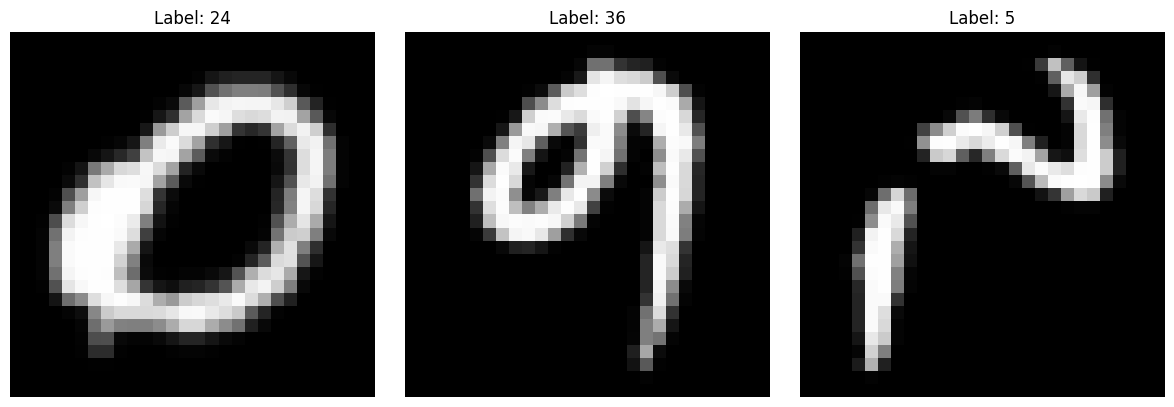

In [124]:
visual.visualizar_imagenes(X_images, y_images, cantidad=3)

Se visualizaron tres imágenes del dataset junto con sus etiquetas correspondientes. Para poder graficarlas, cada imagen fue convertida a una matriz de 28×28 píxeles mediante `reshape(28,28)`. Esto permite recuperar la forma original de la imagen, ya que cada observación representa un carácter manuscrito. Sobre cada imagen se indica su etiqueta numérica, que representa la clase a la que pertenece dentro de las 47 clases posibles del dataset.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.b) Data Splitting
</h3>

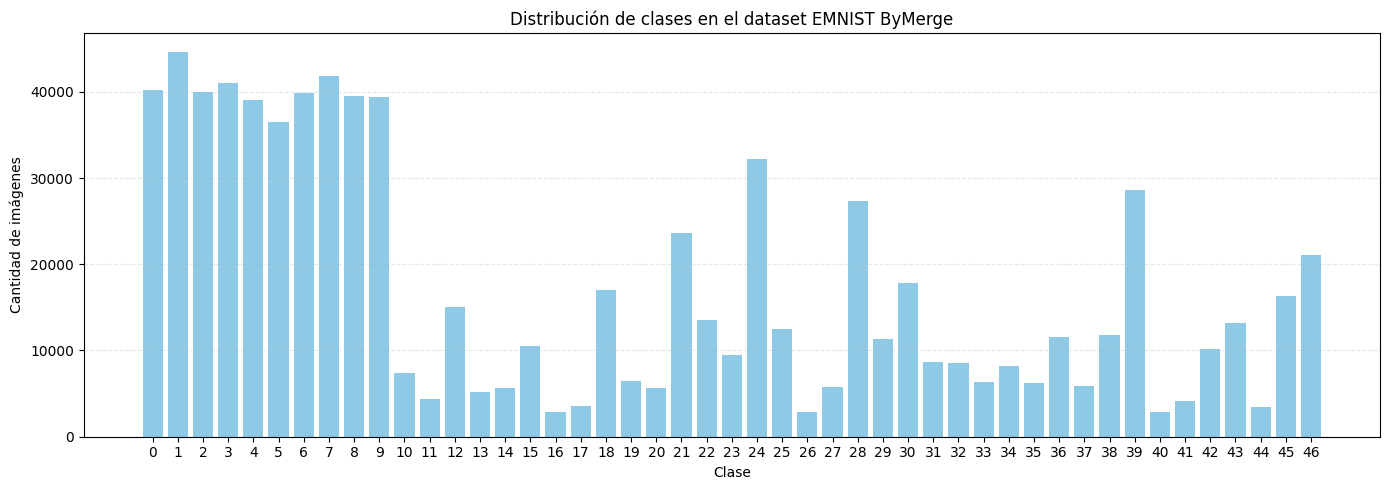

In [125]:
visual.graficar_distribucion_clases(y_images)

Del gráfico se observa que el dataset no está balanceado, ya que algunas clases poseen una cantidad significativamente mayor de ejemplos que otras. Por ejemplo, ciertas clases superan las 40.000 imágenes, mientras que otras apenas contienen unos pocos miles de muestras.

Debido a este desbalance, no resulta conveniente realizar una división completamente aleatoria de los datos, ya que algunas clases minoritarias podrían quedar subrepresentadas en los conjuntos de entrenamiento, validación o test.

Por este motivo, se utiliza *stratified sampling* durante el proceso de *data splitting*. Esta técnica realiza la división manteniendo aproximadamente la misma proporción de ejemplos de cada clase en todos los subconjuntos. De esta manera, train, validation y test conservan una distribución de clases similar a la del dataset original, permitiendo entrenar y evaluar el modelo de manera más representativa y estable

In [126]:
X_tr, X_val, X_test, y_tr, y_val, y_test = split.split_train_val_test(
    X_images,
    y_images,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

Se dividió el dataset en tres subconjuntos: Train, Validation y Test, utilizando una proporción 70/15/15.

El 70% de los datos se asignó al conjunto de entrenamiento, utilizado para ajustar los pesos de la red neuronal durante el aprendizaje. Luego, se reservó un 15% para validación, con el objetivo de comparar configuraciones del modelo y tomar decisiones durante el desarrollo. El 15% restante se dejó como conjunto de test, separado del entrenamiento, para evaluar de manera final la performance sobre datos no vistos.

Esta proporción permite destinar la mayor parte de los ejemplos al entrenamiento, sin perder conjuntos independientes para validar y testear el modelo

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.c) Normalización
</h3>

In [127]:
X_tr = prep.normalizar_imagenes(X_tr)
X_val = prep.normalizar_imagenes(X_val)
X_test = prep.normalizar_imagenes(X_test)

Se normalizaron las imágenes dividiendo todos los valores de píxel por 255. De esta manera, los datos quedaron escalados en el rango [0,1], donde 0 representa el valor mínimo posible y 1 el máximo. La normalización facilita el entrenamiento de la red neuronal, ya que evita trabajar con magnitudes demasiado grandes y mejora la estabilidad numérica del proceso de optimización.

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
2) Red Neuronal Básica
</h1>

In [128]:
# aplanar imágenes: de 28x28 a vectores de 784
X_tr_flat = prep.flatten_imagenes(X_tr)
X_val_flat = prep.flatten_imagenes(X_val)
X_test_flat = prep.flatten_imagenes(X_test)

# one-hot encoding de las etiquetas
y_tr_onehot = prep.one_hot_encode(y_tr, num_classes=47)
y_val_onehot = prep.one_hot_encode(y_val, num_classes=47)
y_test_onehot = prep.one_hot_encode(y_test, num_classes=47)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
2.c) Modelo M0
</h3>

In [95]:
# Modelo M0: 2 capas ocultas de 128 y 64 nodos
M0 = MLP.MLP(layers=[784, 128, 64, 47], random_state=42)

inicio = time.time()

historial_M0 = M0.fit(
    X_train=X_tr_flat,
    y_train=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val_onehot,
    epochs=100,
    learning_rate=0.1
)

tiempo_M0 = time.time() - inicio

historial_M0[historial_M0["epoch"] % 10 == 0]

,epoch,train_loss,val_loss
0,0,4.136270,3.947213
10,10,3.516131,3.477272
20,20,3.088685,3.045358
30,30,2.687595,2.654417
40,40,2.395674,2.372431
50,50,2.182942,2.165547
60,60,2.016060,2.002267
70,70,1.881585,1.870657
80,80,1.771337,1.762594
90,90,1.679904,1.673682


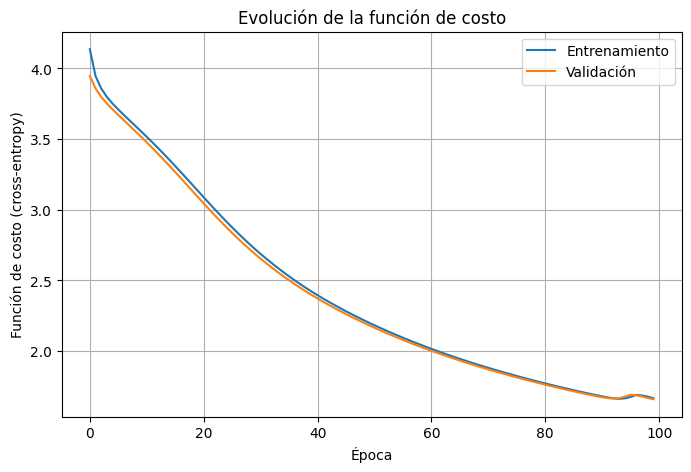

In [96]:
visual.graficar_funcion_costo(historial_M0)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
2.d) Métricas de Performance
</h3>

In [99]:
tabla_train_M0, matriz_train_M0 = util.evaluar_modelo(
    modelo=M0,
    X=X_tr_flat,
    y_true=y_tr,
    y_true_onehot=y_tr_onehot,
    nombre_conjunto="Train",
    num_classes=47
)

tabla_val_M0, matriz_val_M0 = util.evaluar_modelo(
    modelo=M0,
    X=X_val_flat,
    y_true=y_val,
    y_true_onehot=y_val_onehot,
    nombre_conjunto="Validation",
    num_classes=47
)

tabla_metricas = pd.concat([tabla_train_M0, tabla_val_M0], ignore_index=True)
tabla_metricas

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro
0,Train,Train,0.577168,1.658801,0.336551
1,Validation,Validation,0.578157,1.659710,0.338070


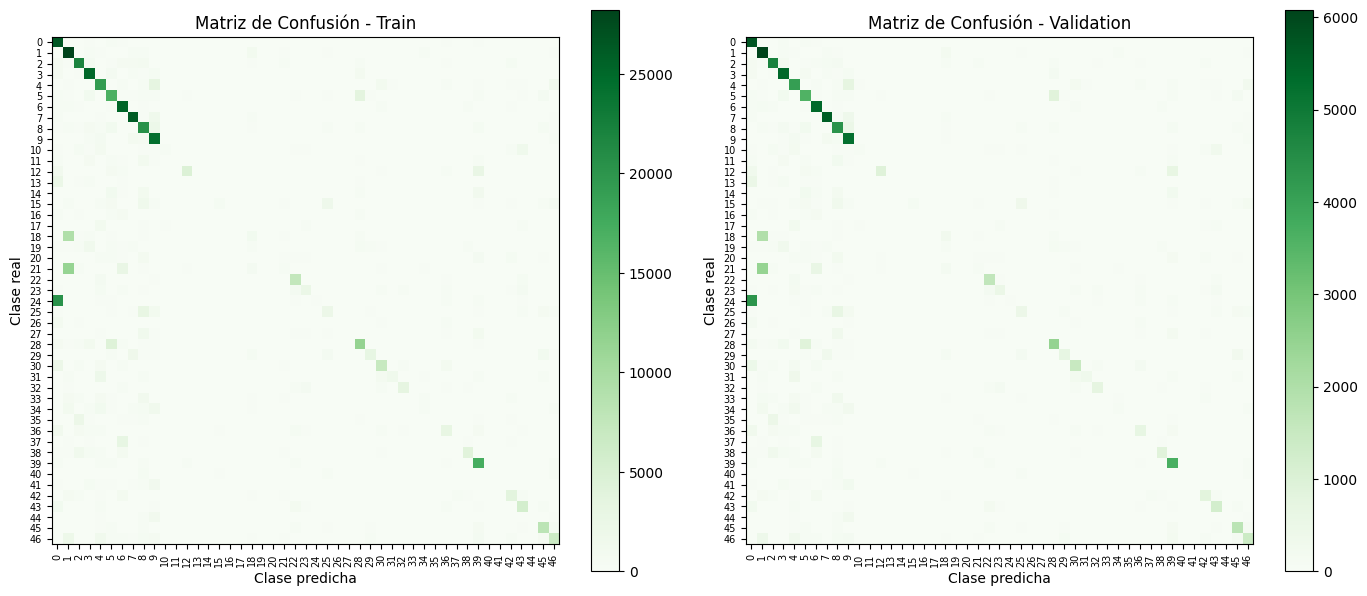

In [100]:
visual.graficar_matrices_confusion(matriz_train_M0, matriz_val_M0)

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
3) Red Neuronal Avanzada
</h1>

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
3.a) Mejoras al Entrenamiento
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Modelo M0
</div>

In [101]:
tabla_val_M0["Modelo"] = "M0"
tabla_val_M0["Tiempo entrenamiento (seg)"] = tiempo_M0

tabla_val_M0

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Tiempo entrenamiento (seg)
0,Validation,M0,0.578157,1.65971,0.33807,232.177954


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Schedule lineal
</div>

In [102]:
modelo_lineal = MLP.MLP([784, 128, 64, 47])

historial_lineal, tabla_lineal, matriz_lineal = util.entrenar_y_evaluar_modelo(
    nombre="Schedule lineal",
    modelo=modelo_lineal,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 40,
        "learning_rate": 0.5,
        "schedule": "linear",
        "lr_final": 0.001,
        "k": 30
    }
)

tabla_lineal

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Tiempo entrenamiento (seg)
0,Schedule lineal,Schedule lineal,0.523985,1.943807,0.252266,196.0915


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Schedule exponencial
</div>

In [104]:
modelo_exp = MLP.MLP([784, 128, 64, 47])

historial_exp, tabla_exp, matriz_exp = util.entrenar_y_evaluar_modelo(
    nombre="Schedule Exponencial",
    modelo=modelo_exp,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 40,
        "learning_rate": 0.1,
        "schedule": "exponential",
        "c": 0.98,
        "s": 1
    }
)

tabla_exp

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Tiempo entrenamiento (seg)
0,Schedule Exponencial,Schedule Exponencial,0.384342,2.766214,0.145678,191.861078


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Mini-batch stochastic gradient descent
</div>

In [106]:
modelo_minibatch = MLP.MLP([784, 128, 64, 47])

historial_minibatch, tabla_minibatch, matriz_minibatch = util.entrenar_y_evaluar_modelo(
    nombre="Mini-batch SGD",
    modelo=modelo_minibatch,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 50,
        "learning_rate": 0.1,
        "batch_size": 256,
        "optimizador": "sgd"
    }
)

tabla_minibatch

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Tiempo entrenamiento (seg)
0,Mini-batch SGD,Mini-batch SGD,0.876345,0.361645,0.840979,225.419673


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Optimizador Adam
</div>

In [107]:
modelo_adam = MLP.MLP([784, 128, 64, 47])

historial_adam, tabla_adam, matriz_adam = util.entrenar_y_evaluar_modelo(
    nombre="Adam",
    modelo=modelo_adam,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 50,
        "learning_rate": 0.001,
        "optimizador": "adam"
    }
)

tabla_adam

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Tiempo entrenamiento (seg)
0,Adam,Adam,0.633333,1.405432,0.412676,228.467326


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Weight decay / Regularización L2
</div>

In [108]:
modelo_l2 = MLP.MLP([784, 128, 64, 47])

historial_l2, tabla_l2, matriz_l2 = util.entrenar_y_evaluar_modelo(
    nombre="Regularización L2",
    modelo=modelo_l2,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 50,
        "learning_rate": 0.5,
        "optimizador": "sgd",
        "l2_lambda": 1e-4
    }
)

tabla_l2

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Tiempo entrenamiento (seg)
0,Regularización L2,Regularización L2,0.604687,1.416861,0.402131,234.649731


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Early Stopping
</div>

In [109]:
modelo_early = MLP.MLP([784, 128, 64, 47])

historial_early, tabla_early, matriz_early = util.entrenar_y_evaluar_modelo(
    nombre="Early Stopping",
    modelo=modelo_early,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 100,
        "learning_rate": 0.3,
        "optimizador": "sgd",
        "early_stopping": True,
        "patience": 10
    }
)

tabla_early

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Tiempo entrenamiento (seg)
0,Early Stopping,Early Stopping,0.648291,1.213156,0.489721,436.342806


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Comparacion entre los modelos
</div>

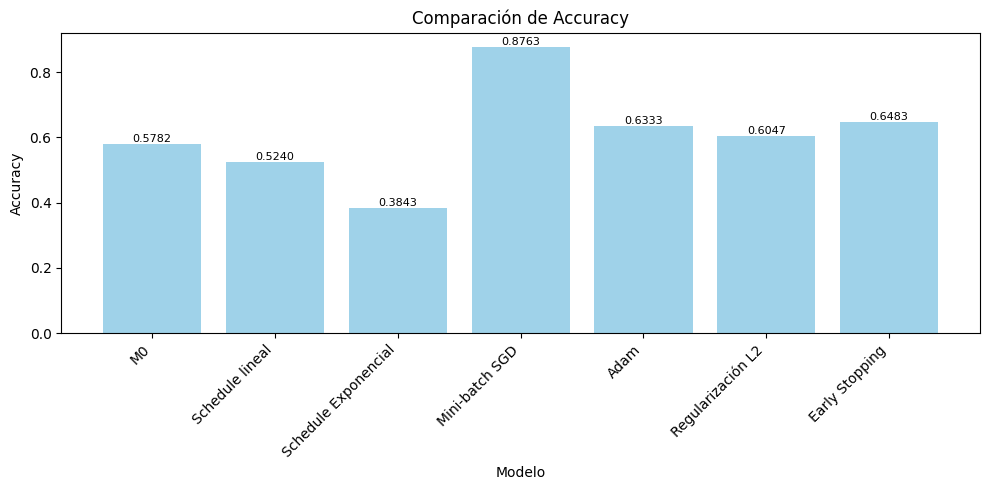

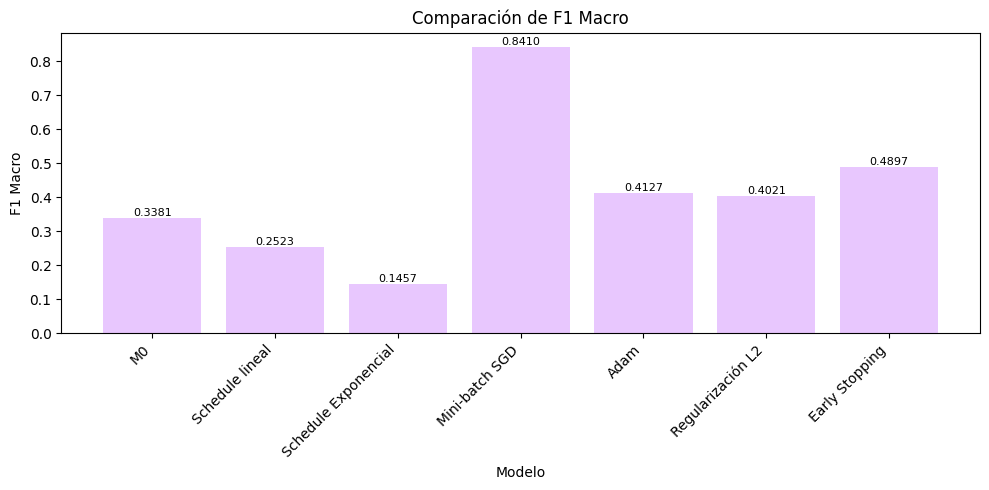

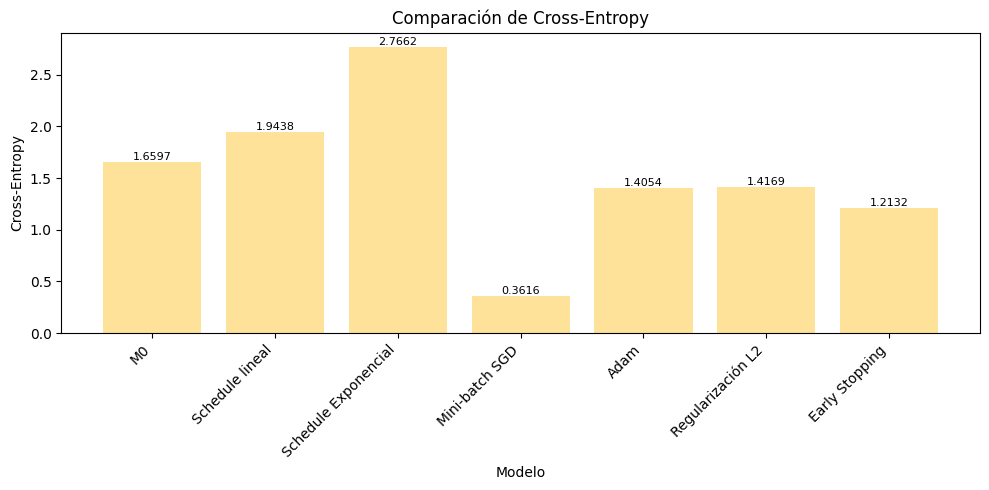

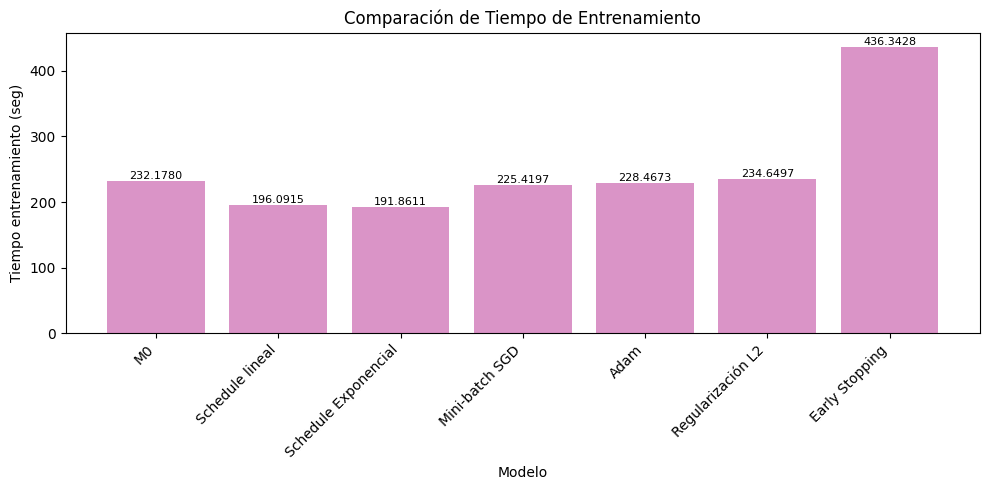

In [129]:
tabla_comparacion = pd.concat(
    [
        tabla_val_M0,
        tabla_lineal,
        tabla_exp,
        tabla_minibatch,
        tabla_adam,
        tabla_l2,
        tabla_early
    ],
    ignore_index=True
)

visual.graficar_comparacion_modelos(tabla_comparacion)

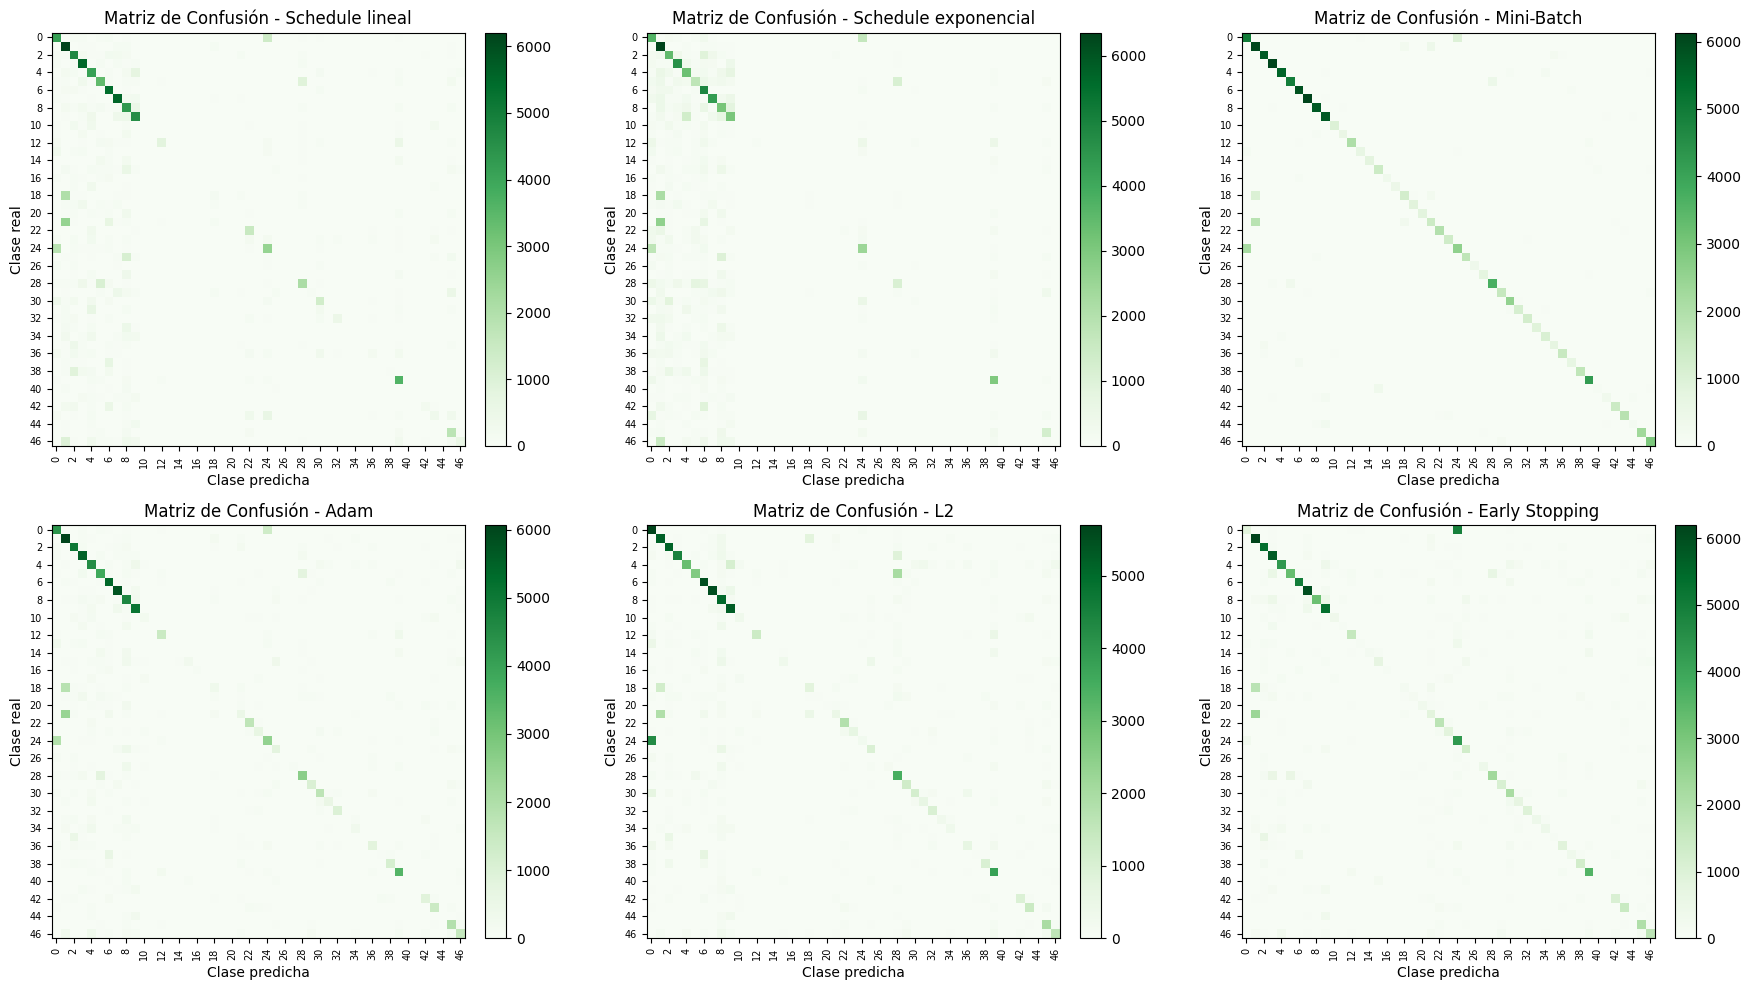

In [130]:
matrices_modelos = [
    matriz_lineal,
    matriz_exp, 
    matriz_minibatch,
    matriz_adam,
    matriz_l2,
    matriz_early
]

nombres_modelos = [
    "Schedule lineal",
    "Schedule exponencial",
    "Mini-Batch",
    "Adam",
    "L2",
    "Early Stopping",
    "Early Stopping + Mini Batch"
]

visual.graficar_matrices_confusion_modelos(matrices_modelos, nombres_modelos)

### Análisis de las mejoras individuales

En esta primera comparación se evalúa cada mejora por separado, manteniendo una arquitectura base común. La idea no es concluir que una técnica sea siempre superior, sino observar cómo se comporta cada modificación bajo las condiciones de entrenamiento elegidas.

A partir de las métricas y los gráficos, **Mini-Batch SGD** aparece como una de las alternativas más favorables dentro de esta prueba. En particular, muestra un mejor equilibrio entre accuracy, cross-entropy y F1 macro que el resto de las mejoras individuales. Esto sugiere que, para este conjunto de hiperparámetros, entrenar con mini-batches resulta más conveniente que entrenar usando todo el conjunto de entrenamiento en cada actualización.

Las demás mejoras no muestran, de manera individual, una ventaja tan clara. **Adam**, **regularización L2** y **Early Stopping** pueden ser técnicas útiles, pero en esta comparación aislada no alcanzan por sí solas el mejor desempeño. Esto no significa que deban descartarse: su efecto puede depender del learning rate, la arquitectura, el batch size o de si se combinan con otras estrategias.

Por último, las matrices de confusión permiten complementar la lectura de las métricas agregadas. En un dataset desbalanceado, una accuracy alta puede estar influida por el desempeño en clases mayoritarias, por lo que también se considera F1 macro para observar mejor el comportamiento promedio entre clases.


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
3.b) 
</h3>

### Combinación de mejoras

Luego de analizar las mejoras individuales, el siguiente paso es probar algunas combinaciones entre ellas. Esto es importante porque una técnica puede no destacarse demasiado por separado, pero sí aportar cuando se usa junto con otra. Por ejemplo, Mini-Batch define cómo se actualizan los pesos durante el entrenamiento, mientras que Early Stopping actúa como criterio de corte y Adam modifica la forma en que se calcula el paso de optimización.

En esta etapa se comparan combinaciones simples manteniendo la misma arquitectura base. El objetivo es elegir una configuración inicial razonable para luego realizar la búsqueda de hiperparámetros del modelo M1.


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Early Stopping + Mini-Batch
</div>

In [ ]:
modelo_early_minibatch = MLP.MLP([784, 128, 64, 47])

historial_early_minibatch, tabla_early_minibatch, matriz_early_minibatch = util.entrenar_y_evaluar_modelo(
    nombre="Mini Batch + Early Stopping",
    modelo=modelo_early_minibatch,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 150,
        "learning_rate": 0.3,
        "optimizador": "sgd",
        "batch_size" : 256,
        "early_stopping": True,
        "patience": 10
    }
)

tabla_early_minibatch

Early stopping en epoch 38


,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Early Stopping + Mini Batch,0.87777,0.358265,0.838992,Early Stopping + Mini Batch,178.505846


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Adam + Mini-Batch
</div>

In [ ]:
modelo_adam_minibatch = MLP.MLP([784, 128, 64, 47])

historial_adam_minibatch, tabla_adam_minibatch, matriz_adam_minibatch = util.entrenar_y_evaluar_modelo(
    nombre="Mini-Batch + Adam",
    modelo=modelo_adam_minibatch,
    X_tr=X_tr_flat,
    y_tr_onehot=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val,
    y_val_onehot=y_val_onehot,
    parametros_fit={
        "epochs": 100,
        "learning_rate": 0.001,
        "batch_size": 256,
        "optimizador": "adam"
    }
)

tabla_adam_minibatch

,Conjunto,Accuracy,Cross-Entropy,F1 Macro,Modelo,Tiempo entrenamiento (seg)
0,Adam + Mini-Batch,0.870266,0.436234,0.829826,Adam + Mini-Batch,434.572998


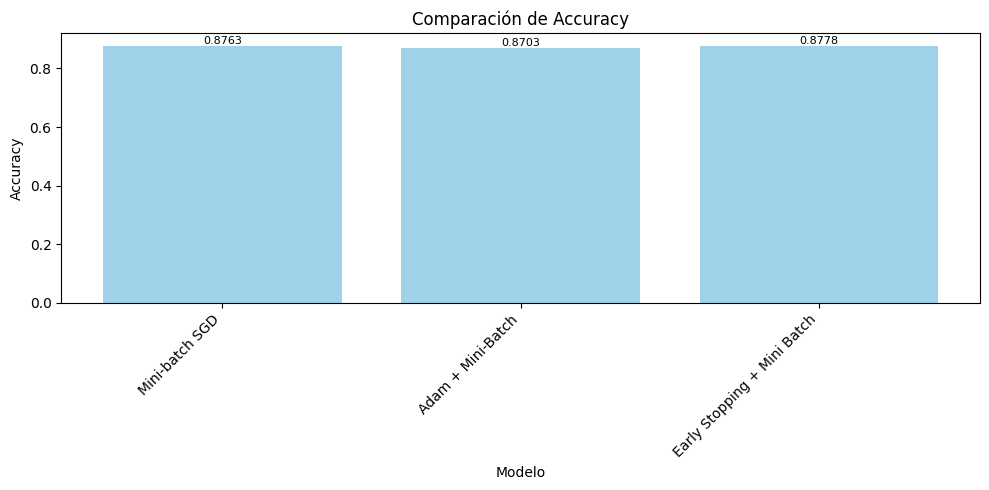

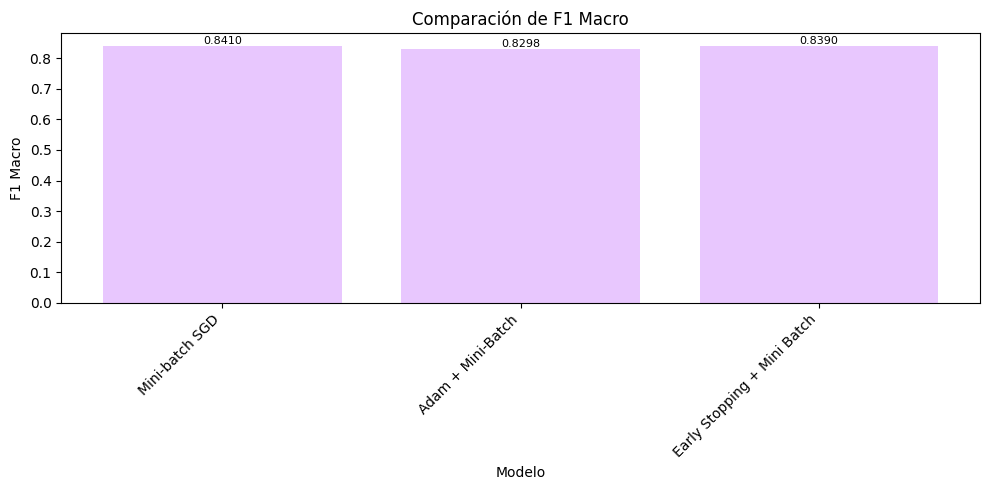

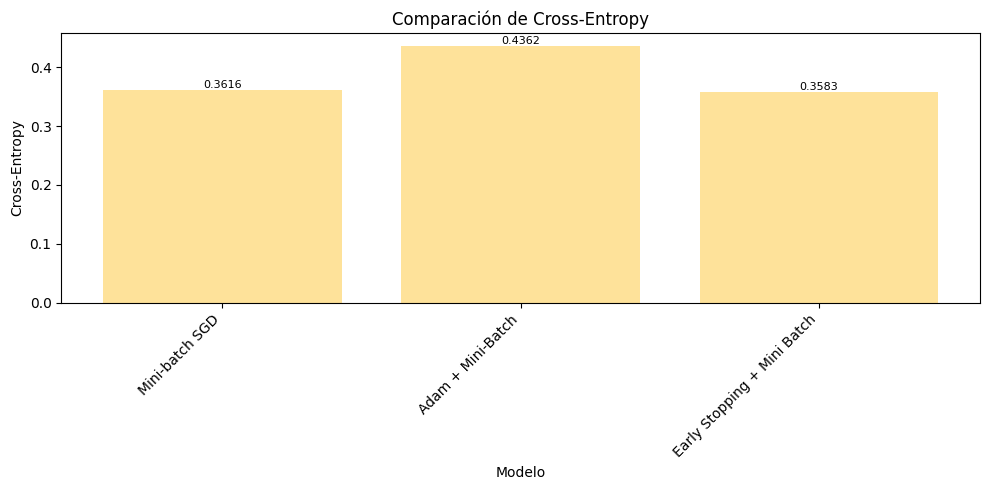

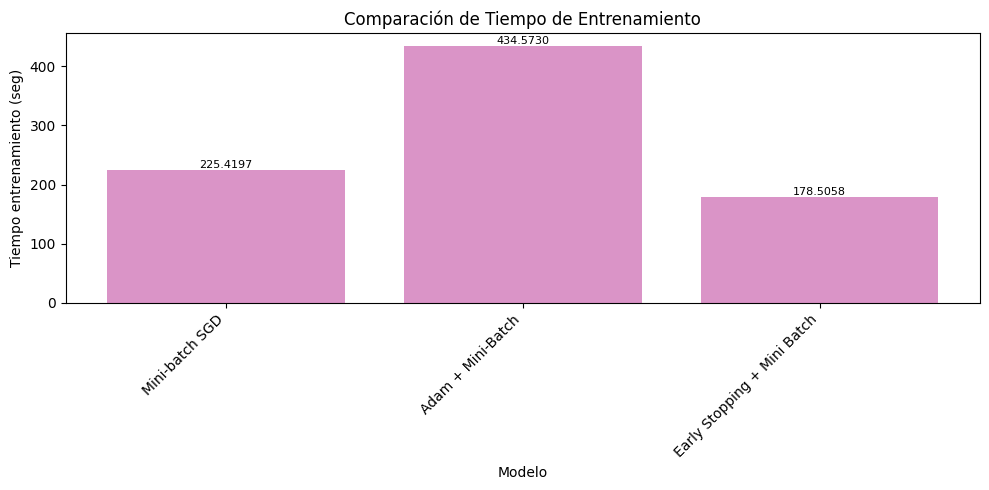

In [131]:
tabla_comparacion = pd.concat(
    [tabla_minibatch, tabla_adam_minibatch, tabla_early_minibatch],
    ignore_index=True
)

visual.graficar_comparacion_modelos(tabla_comparacion)

### Elección del modelo base para M1

A partir de la comparación anterior, se elige **Mini-Batch + Early Stopping** como modelo base para la búsqueda de hiperparámetros de M1. La elección se apoya en dos observaciones: Mini-Batch fue la mejora individual con comportamiento más favorable en esta prueba, y Early Stopping permite controlar el entrenamiento usando el error de validación como referencia.

En la comparación de combinaciones, Mini-Batch + Early Stopping mantiene un desempeño competitivo respecto de las otras alternativas evaluadas. Además, aporta una ventaja práctica: si el modelo deja de mejorar en validación, el entrenamiento puede detenerse antes de completar todas las épocas.

Por lo tanto, esta combinación se toma como punto de partida para M1. No se asume que sea la mejor configuración posible, sino una base razonable sobre la cual explorar arquitectura e hiperparámetros, buscando luego el menor error de validación.


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Hiperparametros
</div>

búsqueda ordenada de configuraciones y elegir la que tenga menor validation loss. Ese modelo elegido pasa a llamarse M1.

Modelo base: Mini Batch con Early Stopping

In [138]:
resultado_busqueda = sgs.stage_grid_search(
    modelo_class=MLP.MLP,
    X_train=X_tr_flat,
    y_train=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val_onehot,
    input_dim=784,
    output_dim=47,
    epochs=30,
    seed=42
)

Early stopping en epoch 23
Early stopping en epoch 26
Early stopping en epoch 17
Early stopping en epoch 16


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Modelo M1
</div>

In [142]:
mejor_config_m1 = resultado_busqueda["mejor_config_m1"]
M1 = resultado_busqueda["mejor_modelo_m1"]

tabla_config_m1 = pd.DataFrame([
    {
        "Modelo": "M1",
        "Arquitectura": str(mejor_config_m1["arquitectura"]),
        "Capas": str(mejor_config_m1["layers"]),
        "Optimizador": mejor_config_m1["optimizer"],
        "Learning rate": mejor_config_m1["learning_rate"],
        "Batch size": mejor_config_m1["batch_size"],
        "Scheduler": mejor_config_m1["scheduler"],
        "Scheduler params": str(mejor_config_m1["scheduler_params"]),
        "Lambda L2": mejor_config_m1["lambda_l2"],
        "Early stopping": mejor_config_m1["early_stopping"],
        "Patience": mejor_config_m1["patience"],
        "Mejor val loss": mejor_config_m1["mejor_val_loss"],
    }
])

tabla_config_m1

,Modelo,Arquitectura,Capas,Optimizador,Learning rate,Batch size,Scheduler,Scheduler params,Lambda L2,Early stopping,Patience,Mejor val loss
0,M1,"[256, 128]","[784, 256, 128, 47]",sgd,0.1,256,linear,"{'lr_final': 0.010000000000000002, 'k': 30}",0.0,True,10,0.329139


<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
4) Desarrollo de una Red Neuronal con PyTorch
</h1>

en PyTorch no hay que pasar y_tr_onehot, sino las etiquetas enteras y_tr, porque nn.CrossEntropyLoss() espera clases como números, no one-hot.

In [144]:
mejor_config_m1 = resultado_busqueda["mejor_config_m1"]

M2, historial_M2, tiempo_M2 = pytorch.entrenar_pytorch_m2(
    layers=mejor_config_m1["layers"],
    X_tr=X_tr_flat,
    y_tr=y_tr,
    X_val=X_val_flat,
    y_val=y_val,
    config_m1=mejor_config_m1,
    epochs=30
)

In [148]:
tabla_m1_val, matriz_m1_val = util.evaluar_modelo(
    M1,
    X_val_flat,
    y_val,
    y_val_onehot,
    nombre_conjunto="M1",
    num_classes=47
)

tabla_m2_val, matriz_m2_val = util.evaluar_modelo_pytorch(
    M2,
    X_val_flat,
    y_val,
    nombre_conjunto="M2 - PyTorch",
    num_classes=47
)

tabla_comparacion_m1_m2 = pd.concat(
    [tabla_m1_val, tabla_m2_val],
    ignore_index=True
)

tabla_comparacion_m1_m2

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro
0,M1,M1,0.884433,0.329139,0.853955
1,M2 - PyTorch,M2 - PyTorch,0.886401,0.325207,0.856276


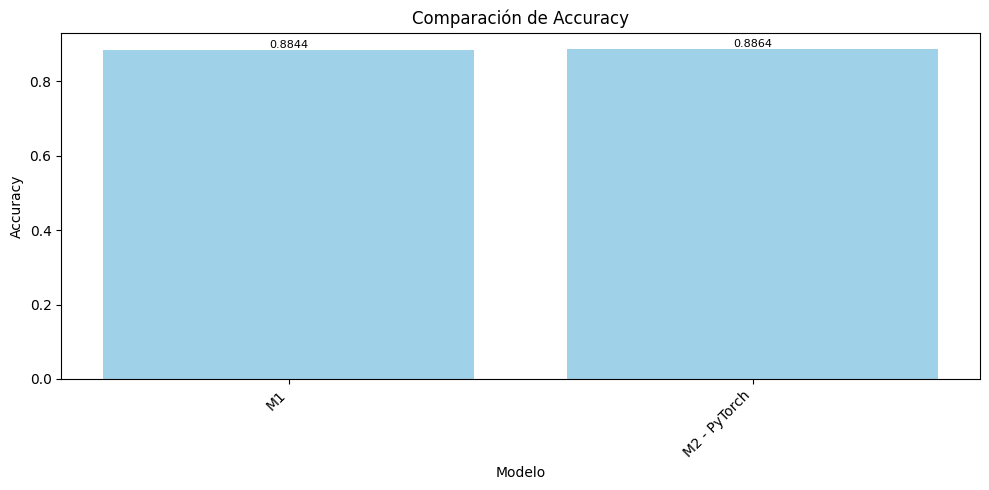

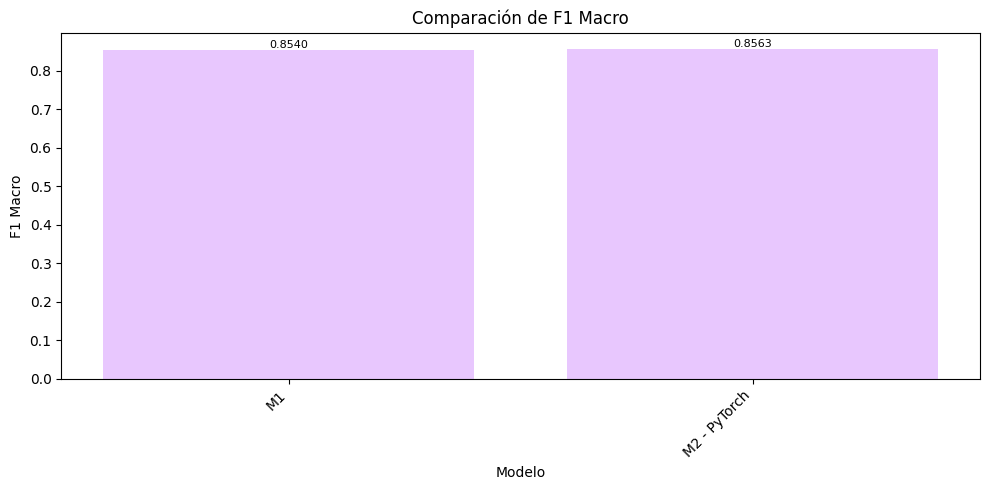

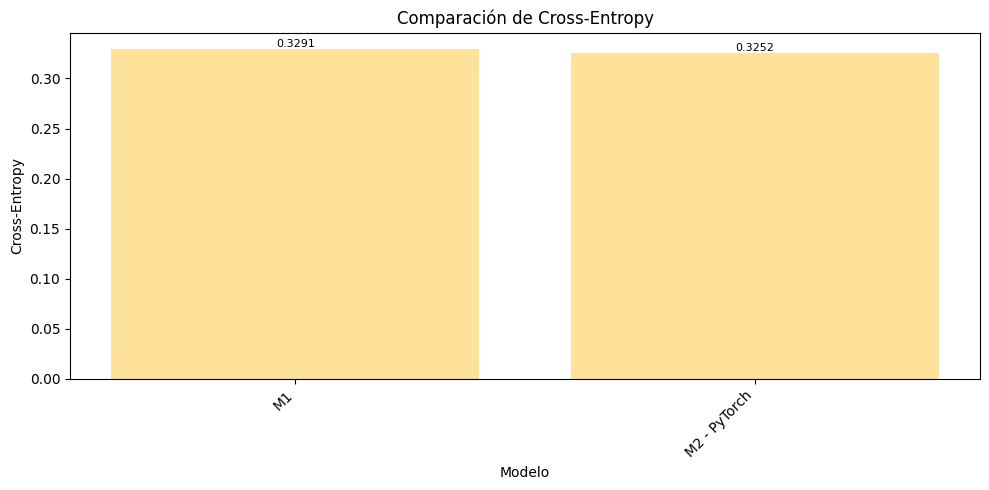

In [149]:
visual.graficar_comparacion_modelos(tabla_comparacion_m1_m2)

### Análisis de la comparación entre M1 y M2

Al comparar M1, implementado con la red neuronal propia, contra M2, implementado en PyTorch usando la misma arquitectura e hiperparámetros elegidos para M1, se observa que ambos modelos tienen un rendimiento muy parecido sobre el conjunto de validación.

En los gráficos, M1 obtiene una accuracy apenas mayor y una cross-entropy apenas menor. Esto indica que, en términos de proporción de aciertos y error promedio de validación, la implementación propia queda levemente por encima. Sin embargo, la diferencia es muy chica, por lo que no parece haber una mejora sustancial de un modelo sobre el otro.

Por otro lado, M2 obtiene un F1 macro apenas mayor. Como esta métrica promedia el desempeño por clase, esto sugiere que PyTorch puede estar equilibrando levemente mejor el rendimiento entre las distintas clases, aunque nuevamente la diferencia es mínima.

En conclusión, los gráficos muestran que ambas implementaciones son consistentes entre sí: entrenadas con la misma configuración, llegan a resultados prácticamente equivalentes. Esto es una buena señal, porque valida que la red implementada manualmente se comporta de forma similar a una implementación estándar en PyTorch.


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
4.b) 
</h3>

In [150]:
resultado_m3 = sgs.stage_grid_search_pytorch(
    X_train=X_tr_flat,
    y_train=y_tr,
    X_val=X_val_flat,
    y_val=y_val,
    input_dim=784,
    output_dim=47,
    config_base=mejor_config_m1,
    epochs=30
)

In [154]:
resultados_completos_m3 = resultado_m3["resultados_completos"]
mejor_config_m3 = resultado_m3["mejor_config_m3"]

tabla_config_m3 = pd.DataFrame([
    {
        "Modelo": "M3",
        "Arquitectura": str(mejor_config_m3["arquitectura"]),
        "Capas": str(mejor_config_m3["layers"]),
        "Optimizador": mejor_config_m3["optimizer"],
        "Learning rate": mejor_config_m3["learning_rate"],
        "Batch size": mejor_config_m3["batch_size"],
        "Scheduler": mejor_config_m3["scheduler"],
        "Scheduler params": str(mejor_config_m3["scheduler_params"]),
        "Lambda L2": mejor_config_m3["lambda_l2"],
        "Early stopping": mejor_config_m3["early_stopping"],
        "Patience": mejor_config_m3["patience"],
        "Activación": mejor_config_m3["activacion"],
        "Dropout": mejor_config_m3["dropout"],
        "Mejor val loss": mejor_config_m3["mejor_val_loss"],
    }
])

tabla_config_m3


,Modelo,Arquitectura,Capas,Optimizador,Learning rate,Batch size,Scheduler,Scheduler params,Lambda L2,Early stopping,Patience,Activación,Dropout,Mejor val loss
0,M3,"[512, 256]","[784, 512, 256, 47]",sgd,0.1,256,linear,"{'lr_final': 0.010000000000000002, 'k': 30}",0.0,True,10,relu,0.1,0.304034


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
4.c) Comparación final sobre test: M0, M1, M2 y M3
</h3>

Una vez seleccionados los modelos usando el conjunto de validación, se evalúa la performance final sobre el conjunto de test. Este conjunto no fue utilizado durante el entrenamiento ni durante la búsqueda de hiperparámetros, por lo que permite estimar mejor la capacidad de generalización de cada modelo.

Se comparan cuatro modelos: M0, correspondiente al modelo base de implementación propia; M1, que es la mejor configuración obtenida con la implementación propia; M2, que reproduce en PyTorch la arquitectura e hiperparámetros de M1; y M3, que corresponde al mejor modelo obtenido mediante la búsqueda realizada en PyTorch.

La comparación se realiza usando accuracy, cross-entropy y F1 macro. Accuracy permite medir la proporción total de aciertos, cross-entropy evalúa la calidad de las probabilidades predichas, y F1 macro permite analizar el desempeño promedio entre clases, lo cual es especialmente importante porque el dataset está desbalanceado.

In [155]:
tabla_m0_test, matriz_m0_test = util.evaluar_modelo(
    M0,
    X_test_flat,
    y_test,
    y_test_onehot,
    nombre_conjunto="M0 - Base propio",
    num_classes=47
)

tabla_m1_test, matriz_m1_test = util.evaluar_modelo(
    M1,
    X_test_flat,
    y_test,
    y_test_onehot,
    nombre_conjunto="M1 - Mejor propio",
    num_classes=47
)

tabla_m2_test, matriz_m2_test = util.evaluar_modelo_pytorch(
    M2,
    X_test_flat,
    y_test,
    nombre_conjunto="M2 - PyTorch mismo M1",
    num_classes=47
)

M3 = resultado_m3["mejor_modelo_m3"]

tabla_m3_test, matriz_m3_test = util.evaluar_modelo_pytorch(
    M3,
    X_test_flat,
    y_test,
    nombre_conjunto="M3 - Mejor PyTorch",
    num_classes=47
)

tabla_comparacion_test = pd.concat(
    [
        tabla_m0_test,
        tabla_m1_test,
        tabla_m2_test,
        tabla_m3_test
    ],
    ignore_index=True
)

tabla_comparacion_test

,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro
0,M0 - Base propio,M0 - Base propio,0.575890,1.664562,0.336308
1,M1 - Mejor propio,M1 - Mejor propio,0.886366,0.327638,0.855466
2,M2 - PyTorch mismo M1,M2 - PyTorch mismo M1,0.887033,0.324231,0.856641
3,M3 - Mejor PyTorch,M3 - Mejor PyTorch,0.892705,0.303252,0.863363


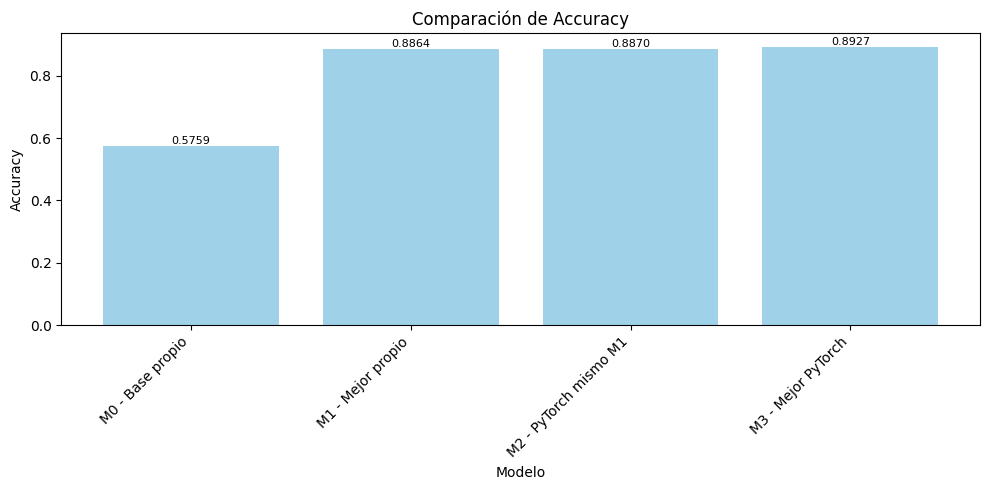

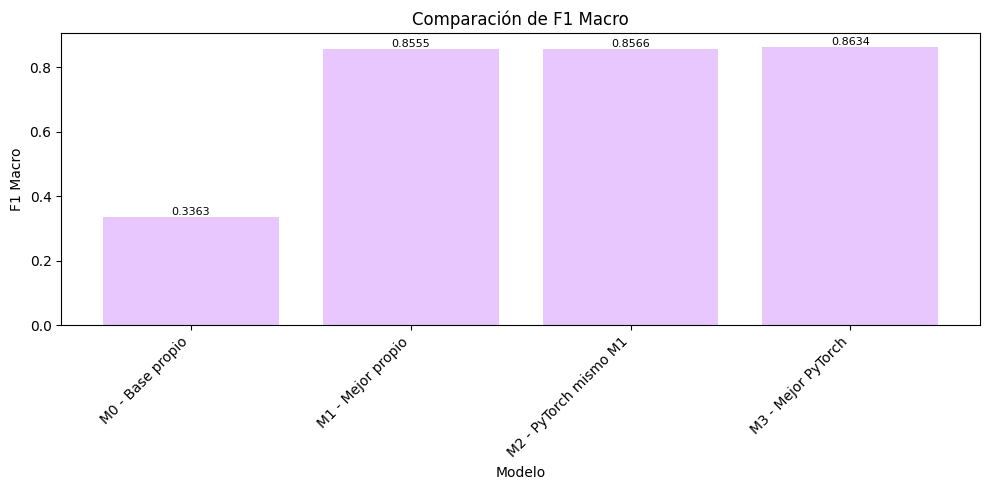

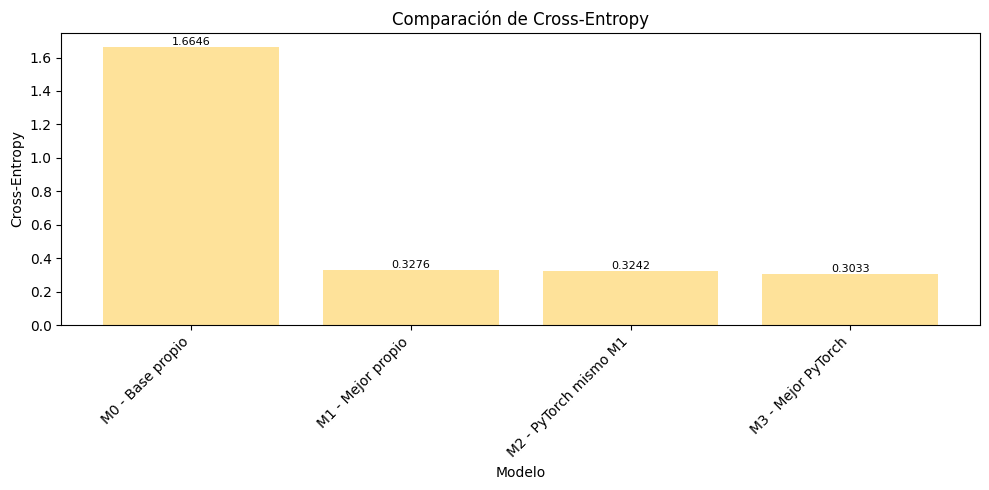

In [156]:
visual.graficar_comparacion_modelos(tabla_comparacion_test)

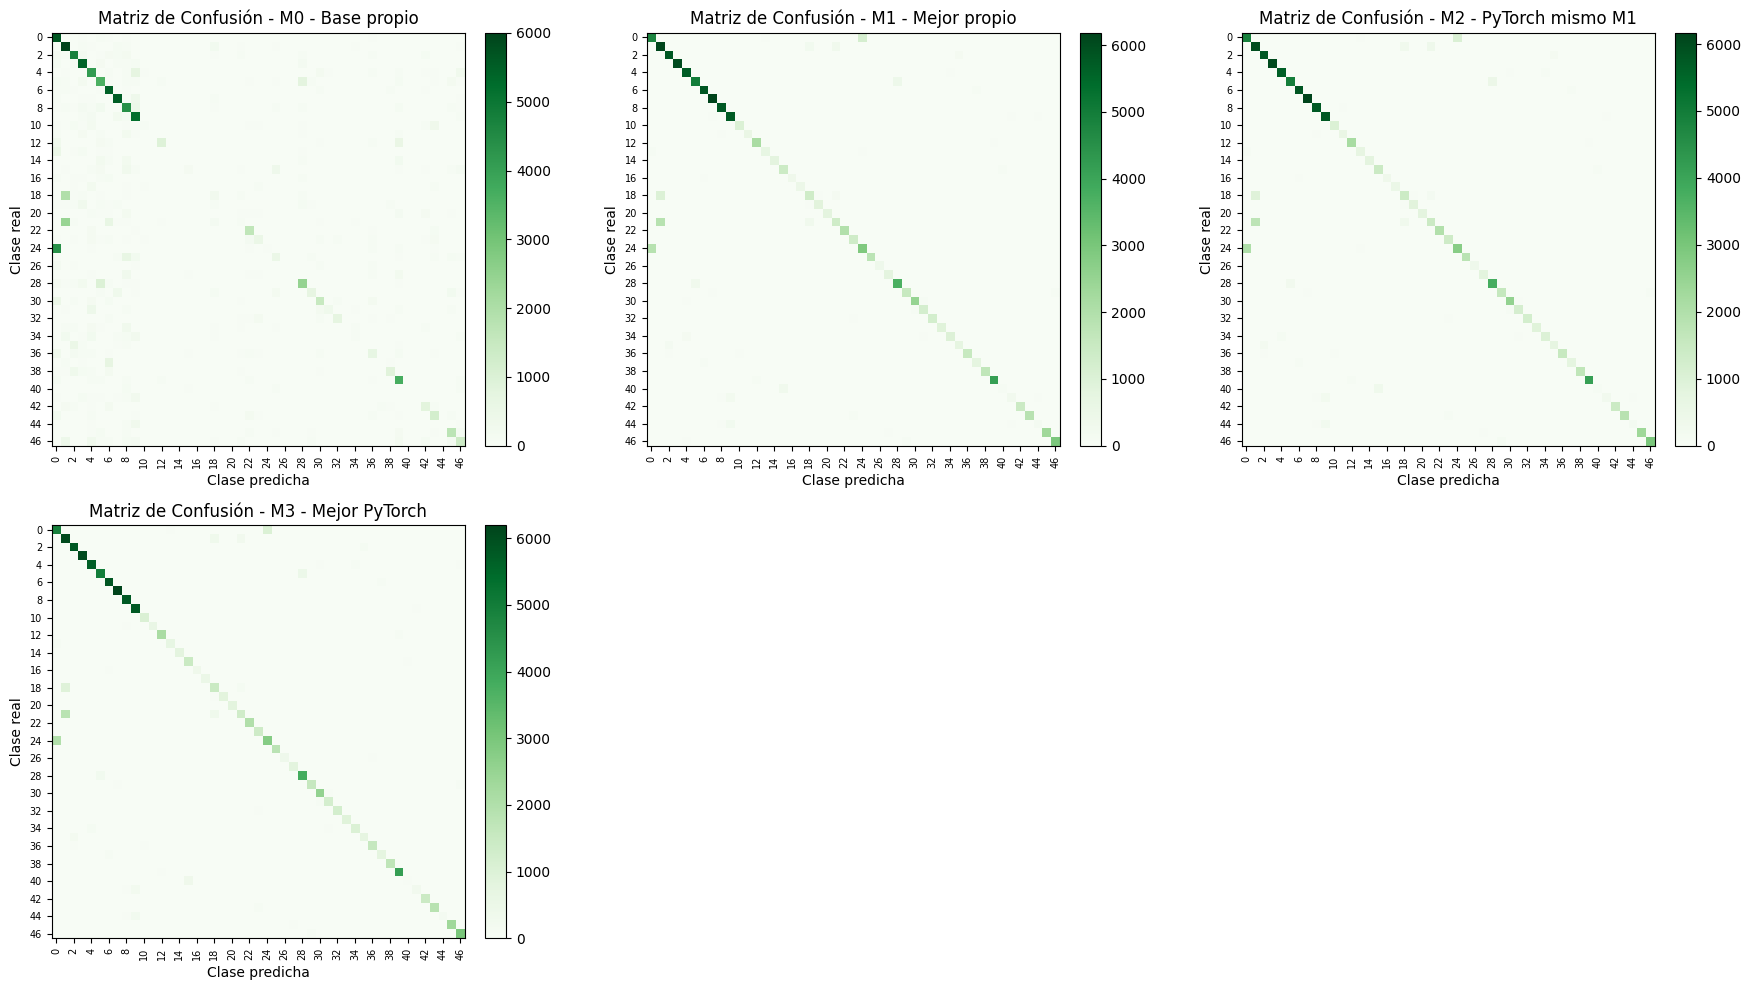

In [157]:
matrices_test = [
    matriz_m0_test,
    matriz_m1_test,
    matriz_m2_test,
    matriz_m3_test
]

nombres_test = [
    "M0 - Base propio",
    "M1 - Mejor propio",
    "M2 - PyTorch mismo M1",
    "M3 - Mejor PyTorch"
]

visual.graficar_matrices_confusion_modelos(matrices_test, nombres_test)


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
4.d) Robustez frente a ruido
</h3>

Para evaluar la robustez de los modelos, se perturba el conjunto de test agregando ruido gaussiano de distinta intensidad. Los modelos no se vuelven a entrenar: solamente se evalúan sobre versiones cada vez más ruidosas de los mismos datos de test.

El caso con sigma igual a 0 corresponde al test original sin perturbar. A medida que aumenta sigma, las imágenes se alejan más de los datos originales, por lo que se espera una degradación progresiva en las métricas.

La robustez de cada modelo se analiza comparando la caída de accuracy y F1 macro, junto con el aumento de cross-entropy, respecto del caso sin ruido. Un modelo más robusto será aquel cuya performance se degrade más lentamente al aumentar el nivel de perturbación.

1. parto de X_test_flat -> normalizado en [0,1]
2. agrego ruido -> X_test_ruidoso = X_test_flat + ruido
3. recorto los valores para que sigan estando e [0,1] -> X_test_ruidoso = np.clip(X_test_ruidoso, 0, 1)
4. evaluo los modelos sobre cada nivel de ruido
5. comparo las metricas contra el test sin ruido

In [158]:
M3 = resultado_m3["mejor_modelo_m3"]

modelos_propios = {
    "M0 - Base propio": M0,
    "M1 - Mejor propio": M1,
}

modelos_pytorch = {
    "M2 - PyTorch mismo M1": M2,
    "M3 - Mejor PyTorch": M3,
}

niveles_ruido = [0.0, 0.05, 0.1, 0.2, 0.3]

tabla_robustez = util.evaluar_modelos_con_ruido(
    modelos_propios=modelos_propios,
    modelos_pytorch=modelos_pytorch,
    X_test=X_test_flat,
    y_test=y_test,
    y_test_onehot=y_test_onehot,
    niveles_ruido=niveles_ruido,
    num_classes=47
)

tabla_robustez


,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Ruido sigma
0,M0 - Base propio,M0 - Base propio,0.575890,1.664561,0.336308,0.00
1,M1 - Mejor propio,M1 - Mejor propio,0.886366,0.327638,0.855466,0.00
2,M2 - PyTorch mismo M1,M2 - PyTorch mismo M1,0.887033,0.324231,0.856641,0.00
3,M3 - Mejor PyTorch,M3 - Mejor PyTorch,0.892705,0.303252,0.863363,0.00
4,M0 - Base propio,M0 - Base propio,0.574359,1.683523,0.335552,0.05
5,M1 - Mejor propio,M1 - Mejor propio,0.879814,0.349833,0.847150,0.05
6,M2 - PyTorch mismo M1,M2 - PyTorch mismo M1,0.883082,0.340909,0.852867,0.05
7,M3 - Mejor PyTorch,M3 - Mejor PyTorch,0.890301,0.314087,0.860698,0.05
8,M0 - Base propio,M0 - Base propio,0.569272,1.713982,0.332059,0.10
9,M1 - Mejor propio,M1 - Mejor propio,0.845750,0.459161,0.800475,0.10


In [159]:
tabla_robustez_completa = util.agregar_caida_respecto_limpio(tabla_robustez)
tabla_robustez_completa


,Conjunto,Modelo,Accuracy,Cross-Entropy,F1 Macro,Ruido sigma,Accuracy limpio,Cross-Entropy limpio,F1 Macro limpio,Caida Accuracy,Aumento Cross-Entropy,Caida F1 Macro
0,M0 - Base propio,M0 - Base propio,0.575890,1.664561,0.336308,0.00,0.575890,1.664561,0.336308,0.000000,0.000000,0.000000
1,M1 - Mejor propio,M1 - Mejor propio,0.886366,0.327638,0.855466,0.00,0.886366,0.327638,0.855466,0.000000,0.000000,0.000000
2,M2 - PyTorch mismo M1,M2 - PyTorch mismo M1,0.887033,0.324231,0.856641,0.00,0.887033,0.324231,0.856641,0.000000,0.000000,0.000000
3,M3 - Mejor PyTorch,M3 - Mejor PyTorch,0.892705,0.303252,0.863363,0.00,0.892705,0.303252,0.863363,0.000000,0.000000,0.000000
4,M0 - Base propio,M0 - Base propio,0.574359,1.683523,0.335552,0.05,0.575890,1.664561,0.336308,0.001531,0.018962,0.000756
5,M1 - Mejor propio,M1 - Mejor propio,0.879814,0.349833,0.847150,0.05,0.886366,0.327638,0.855466,0.006553,0.022195,0.008315
6,M2 - PyTorch mismo M1,M2 - PyTorch mismo M1,0.883082,0.340909,0.852867,0.05,0.887033,0.324231,0.856641,0.003951,0.016678,0.003775
7,M3 - Mejor PyTorch,M3 - Mejor PyTorch,0.890301,0.314087,0.860698,0.05,0.892705,0.303252,0.863363,0.002404,0.010835,0.002666
8,M0 - Base propio,M0 - Base propio,0.569272,1.713982,0.332059,0.10,0.575890,1.664561,0.336308,0.006618,0.049420,0.004249
9,M1 - Mejor propio,M1 - Mejor propio,0.845750,0.459161,0.800475,0.10,0.886366,0.327638,0.855466,0.040616,0.131523,0.054990
